# Benchmarking on human lymphnode data and mouse hippocampus data

This notebook aims to reproduce the quantitative evaluation results on two datasets: the human lymph node A1 dataset, evaluated using six supervised metrics, and the simulated triplet omics dataset, evaluated using Moran’s I score.

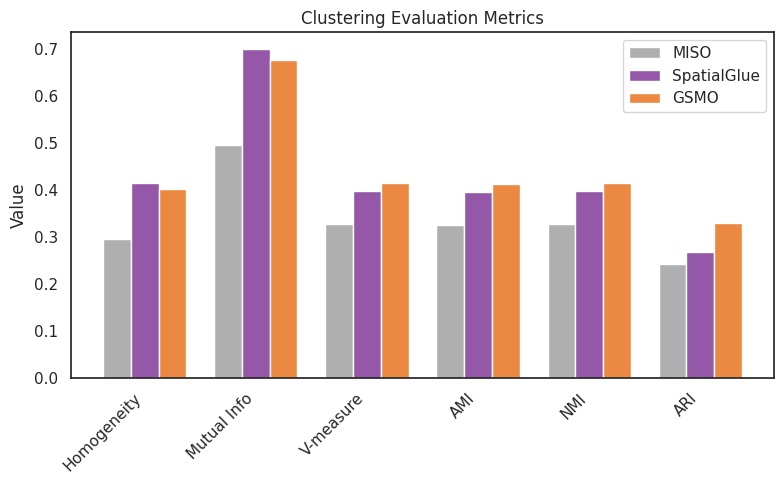

[OK] saved: ../Figure/clustering_metrics_Lymphnode.png


In [ ]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# baseline settings
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 15
sns.set(style="white", font_scale=1.0)

RESULT_DIR = "../result/Fig3/"
CSV_PATH   = os.path.join(RESULT_DIR, "metrics_Lymphnode.csv")
FIG_DIR    = "../Figure/"
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
df.head()


# fixed order & colors
methods_order = ['MISO', 'SpatialGlue', 'GSMO']
method_colors = {
    'MISO': '#afafaf',
    'SpatialGlue': '#9558a8ff',
    'GSMO': '#eb8841'
}
metrics_order = ['Homogeneity','Mutual Info','V-measure','AMI','NMI','ARI']

df_clu = df[df['MetricGroup']=='clustering'].copy()
wide = df_clu.pivot_table(index='Method', columns='Metric', values='Value', aggfunc='first')

metrics_plot = [m for m in metrics_order if m in wide.columns]
wide = wide.reindex(index=methods_order).loc[:, metrics_plot]

x = np.arange(len(metrics_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(8,5))
for i, m in enumerate(methods_order):
    vals = wide.loc[m, metrics_plot].values.astype(float)
    ax.bar(x + (i-1)*width, vals, width, label=m, color=method_colors[m])

ax.set_ylabel('Value')
ax.set_xticks(x)
ax.set_xticklabels(metrics_plot, rotation=45, ha='right')
ax.set_title('Clustering Evaluation Metrics')
ax.legend()
plt.tight_layout()

out_bar = os.path.join(FIG_DIR, "clustering_metrics_Lymphnode.png")
plt.savefig(out_bar, dpi=500, bbox_inches='tight')
plt.show()
print(f"[OK] saved: {out_bar}")


/tmp/ipykernel_1493603/742038800.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


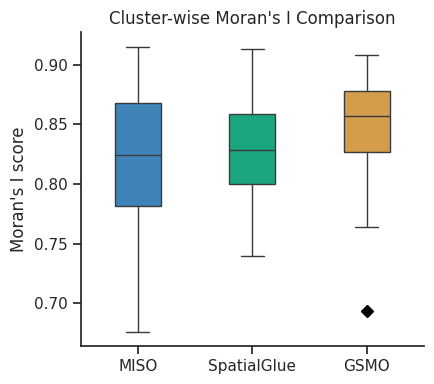

[OK] saved: ../Figure/moran_boxplot_Hippocampus.png


In [ ]:
# Evaluation results on Hippocampus dataset
RESULT_DIR = "../result/Fig3/"
CSV_PATH   = os.path.join(RESULT_DIR, "metrics_Hippocampus.csv")
FIG_DIR    = "../Figure/"
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
df.head()

# Moran's I score
order = ['MISO','SpatialGlue','GSMO']
palette = {'MISO':'#2987ce','SpatialGlue':'#05bd89','GSMO':'#e9a135'}

df_m = df[df['MetricGroup']=='moran'].copy()
df_m = df_m.rename(columns={'Value':'MoransI'})

plt.figure(figsize=(4.5,4))
ax = sns.boxplot(
    data=df_m, x='Method', y='MoransI',
    order=order, palette=palette,
    width=0.4, fliersize=6,
    flierprops=dict(marker='D', markerfacecolor='black', markeredgecolor='black')
)

sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
ax.tick_params(bottom=True, left=True)
plt.ylabel("Moran's I score")
plt.xlabel("")
plt.title("Cluster-wise Moran's I Comparison")
plt.tight_layout()

out_box = os.path.join(FIG_DIR, "moran_boxplot_Hippocampus.png")
plt.savefig(out_box, dpi=400, bbox_inches='tight')
plt.show()
print(f"[OK] saved: {out_box}")
